# Day 021 · 希腊字母全解析 · 中国版
**The Greeks** · 阶段 P1 · 量化基础

> 希腊字母是 BS 公式的导数家族 — Δ Γ Θ Vega Rho 五个,分别表示期权价格对标的价 / 标的价的二阶 / 时间 / 波动率 / 利率的敏感度。这一节我们做两件事:① 把五个希腊字母的解析公式从 BS 公式直接微分推出来,然后用 numpy + matplotlib 画 Δ-Γ-Θ-Vega 在「标的价 × 时间」二维网格上的曲面,你会一眼看出 Γ 和 Vega 在 ATM + 短期最爆,Θ 在 ATM + 临近到期损失最快;② 演示实战中最常用的对冲技巧 — Δ 中性和 Δ-Γ 中性组合怎么搭,为什么期权交易员每天的工作就是「用一些期权 + 股票拼出符合期望希腊敞口的组合」。课结束时你应该能看着一张希腊字母曲面图直接说出「卖 ATM call 临近到期最危险」「Vega 在长期期权上最大」「Theta 损失加速到 2 / √T」等专业结论。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-12  ·  **建议学习时长:** 24 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _retry(fn, *args, _retries=4, _wait=1.5, **kwargs):
    """akshare 上游(东方财富/新浪/Binance)偶有 RemoteDisconnected / Timeout,自动重试 4 次。
    2026-05-11 加:用户跑 cn notebook 拉 002594.SZ 时上游断连 → 整节卡死。
    每次重试间隔 _wait 秒(指数退避 1x → 1.5x → 2.25x)。
    """
    import time as _t
    last_err = None
    wait = _wait
    for i in range(_retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_err = e
            name = type(e).__name__
            if i == _retries - 1:
                print(f"  ✗ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次仍失败({name}),放弃")
                raise
            print(f"  ⚠ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次失败({name}),{wait:.1f}s 后重试")
            _t.sleep(wait)
            wait *= 1.5

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。
    所有 ak.* 调用都过 _retry(4 次,指数退避)— 防东方财富/新浪上游瞬时断连。
    """
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(_retry(ak.stock_zh_a_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(_retry(ak.fund_etf_hist_em, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(_retry(ak.stock_zh_index_daily_em, symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(_retry(ak.stock_hk_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        s = _norm(_retry(ak.stock_us_daily, symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(_retry(ak.index_us_stock_sina, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(_retry(ak.futures_foreign_hist, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        import requests as _rq
        def _binance():
            r = _rq.get("https://api.binance.com/api/v3/klines",
                        params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
            r.raise_for_status()
            return r.json()
        klines = _retry(_binance)
        df = pd.DataFrame(klines, columns=["open_time","open","high","low","close","volume",
                                            "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 看懂五个希腊字母的解析公式,知道每个都从 BS 哪一步推出来
- 用 numpy + matplotlib 画 Δ-Γ-Θ-Vega 在「标的价 × 时间」二维曲面图,识别每个希腊的「热点」
- 理解 Γ 在 ATM + 短期最大,Theta 在 ATM + 临近到期损失最快,Vega 在长期期权上最大
- 搭建 Δ 中性 / Δ-Γ 中性组合,看懂期权交易员每天怎么用希腊字母管头寸
- 明白「期权到期前最后一周 Theta 爆炸」的数学原因(Theta ~ 1/√T)和实战含义

## 历史背景:希腊字母 1973 — 从 BS 推导出来的对冲工具家族

希腊字母没有「单独被发明」的历史 — 它们就是 BS 公式的偏导数,从 BS 一九七三年发表那天起就同时存在。但**让希腊字母变成行业标准的人**是一九七零年代末到八零年代芝加哥期权交易所的做市商。

**故事的主角**是 Mark Rubinstein(就是 CRR 二叉树那个 Rubinstein)和 Hayne Leland。他们一九七六年提出**组合保险**(portfolio insurance) — 用动态调整 Δ 来给股票组合做「保险」,效果等价于持有一份 put。这个产品在一九八零年代风靡华尔街,但**一九八七年黑色星期一直接证伪了**:股价跳跌时 Δ 对冲来不及调,损失放大。这是希腊字母从「教科书」走到「实战工具」的标志事件。

之后做市商发现单看 Δ 不够,Γ(对 Δ 的敏感度)同样重要 — 没控制 Γ 你的对冲组合在大波动时也会失灵。再后来 Vega(对波动率)和 Theta(对时间)都成了标准头寸管理指标,做市商每天交易系统报告的就是「我现在 Δ 多 / 少多少,Γ 多 / 少多少,Vega 多 / 少多少,Theta 每天损失多少」。这套语言从美国扩到香港、伦敦、东京,成为全球期权交易的工作语言。

**为什么用希腊字母而不直接用价**?因为价格随标的价 / 时间 / 波动率 / 利率同时变化,看价格变化你不知道是哪个变量驱动的。希腊字母**把价格变化拆成五个独立维度**,你可以分别管控。这是金融工程从「直觉」到「量化」的关键飞跃 — 不只期权,所有衍生品(债券 duration / convexity 也是希腊字母的远房亲戚)都用类似框架。

本课不让你重新推希腊公式 — 那是大学一年级偏导数题。我们用 BS 直接给公式,然后**画曲面 + 演示组合**,让你看出希腊字母的「形状」和「用法」。理解形状你才能在实战中预判:卖 ATM call 临近到期为什么爆炸、为什么交易员要尽量避开短期 ATM、为什么 Vega 长期期权上最大。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. Δ(Delta)— 期权价对标的价的一阶导

**定义**:Δ = ∂C/∂S

**金融含义**:标的价涨 1 元,期权价大约涨 Δ 元。

**Call 公式**:Δ_call = N(d_1) ∈ [0, 1]
**Put 公式**:Δ_put = -N(-d_1) = N(d_1) - 1 ∈ [-1, 0]

**直观特性**:
- 深 OTM call(K >> S):Δ ≈ 0(几乎没价值,股价小变化不影响)
- ATM call(K = S):Δ ≈ 0.5(平值,价格变化的一半反映在期权)
- 深 ITM call(K << S):Δ ≈ 1(等于股票,完全反映价变)
- Put 是负的,做空 1 份 put 等价于「轻微做多股票」

**临近到期 Δ 形状变陡**(变成「越过 K 跳一下」):远期 ATM call 的 Δ 在 S = K ± 5% 之间平滑过渡,临近到期 Δ 在 S = K 附近从 0.1 跳到 0.9,在 K 处接近阶跃函数。

**实战用法 — Δ 对冲**:
- 卖 1 份 Δ = 0.6 的 call,买 0.6 股股票 → 净 Δ = 0,股价小变化时组合损益不变
- 头寸的 Δ 加权和叫**净 Delta**,做市商每天目标是把净 Delta 维持在 ±5% 以内

**Δ 不是概率**(虽然 N(d_2) 是概率)— Δ = N(d_1),里面那个 d_1 跟 d_2 差 σ √T,所以 Δ 略大于「到期 in-the-money 的概率」。

```
Δ_call = N(d_1)   //   Δ_put = N(d_1) - 1   //   d_1 = [ln(S/K) + (r+σ²/2)T] / (σ√T)
```

> **举例:** 标普 ETF 当前 500,1 个月期 K=500 的 ATM call Δ ≈ 0.55。你卖一份(看跌但不愿全部下注),要对冲就买 0.55 × 100 = 55 股 SPY(每份合约 100 股)。如果 SPY 涨到 510,你的 call 损失约 5 × 0.55 = 2.75 美元,但股票赚 0.55 × 10 = 5.5 美元。净赚 ≈ 0(小波动 + 期权 Γ 损失)。


### 2. Γ(Gamma)— Δ 的导数 / 凸性

**定义**:Γ = ∂Δ/∂S = ∂²C/∂S²

**金融含义**:标的价涨 1 元,Δ 大约涨 Γ。也就是「Δ 变化得多快」。

**Call 公式**(call 和 put 一样):Γ = φ(d_1) / (S × σ × √T),其中 φ 是标准正态密度

**直观特性**:
- Γ 在 **ATM(K = S)+ 短期(T 小)** 时最大
- 深 OTM 和深 ITM 时 Γ ≈ 0(Δ 已经接近 0 或 1,变化不大)
- 临近到期 Γ 爆炸(临近到期 ATM 期权的 Δ 变化最剧烈)

**Γ 的实战含义**:
- 高 Γ = 「对冲组合不稳定」(Δ 一直变,要频繁调)
- 低 Γ = 「对冲组合稳定」(Δ 不怎么变,可以低频调)
- 期权交易员**讨厌做空高 Γ 头寸**(卖 ATM 短期期权)→ 因为对冲成本高 + 路径风险大

**Γ-loss / Γ-pnl**:对冲组合的瞬时损益 ≈ -0.5 × Γ × dS²。如果你做空高 Γ 期权,股价剧烈波动会让你 Γ 损失爆炸。所以「卖 ATM 短期 call」是经典的「捡硬币 vs 蒸汽压路机」反指头寸。

**实战用法 — Δ-Γ 中性组合**:用一份期权 + 另一份不同 K 的期权,凑出 Γ = 0,再用股票凑 Δ = 0。这种组合对小波动 + 中等波动都稳定,但对极端波动(超出对冲范围)仍会失灵。

```
Γ = φ(d_1) / (S × σ × √T)   //   ATM 短期 Γ 最大,深 OTM/ITM Γ ≈ 0
```

> **举例:** 标普 ETF 500,1 周期 ATM call Γ ≈ 0.05(意思是 SPY 涨 1 美元,Δ 涨 5 个百分点)。如果你卖一份 → SPY 突然涨到 510,Δ 从 0.5 跳到接近 1.0,你之前买的对冲股票远不够,损失约 0.5 × Γ × 10² = 2.5 美元 / 份(实际更多因为 Vega 同时跳)。卖短期 ATM 是高风险动作。


### 3. Θ(Theta)— 时间衰减

**定义**:Θ = ∂C/∂t(注意符号 — 时间的「过去」是 -dt,Θ 通常是负数)

**金融含义**:每过一天,期权价大约损失 -Θ 元(Θ 通常是负的,所以 -Θ 是正损失)。

**Call 公式**:Θ_call = -[S × φ(d_1) × σ / (2 × √T)] - r × K × e^(-rT) × N(d_2)
**Put 公式**:Θ_put = -[S × φ(d_1) × σ / (2 × √T)] + r × K × e^(-rT) × N(-d_2)

通常 call 的 Theta 比 put 略多负(因为 -rK 项是负的对 call,正的对 put)。

**直观特性**:
- ATM 期权的 Theta 最大(最快损失时间价值)
- 深 ITM 和深 OTM 的 Theta 较小(已经接近内在价值或几乎无价值)
- **Theta 加速**:Theta ~ 1/√T,所以临近到期(T → 0)时 Theta 爆炸式衰减

**「Theta 每天损失」 vs 「Theta 加速到期」**:
- 远期 1 年期 ATM call:Theta/天 约 -0.02(每天损失 2 分)
- 1 月期 ATM call:Theta/天 约 -0.06(每天损失 6 分)
- 1 周期 ATM call:Theta/天 约 -0.15(每天损失 15 分)
- 1 天期 ATM call:Theta/天 约 -0.50(最后一天损失大半)

**实战策略**:
- **卖期权(short premium)策略** = 主动收 Theta,但承担 Γ 和 Vega 风险。Wheel 策略 / 备兑开仓 cover call / 现金担保 put 都属于这一类。
- **买期权(long premium)策略** = 付 Theta,但赚 Γ 和 Vega。事件驱动(财报 / 政策)用得多。
- **Theta-Vega 平衡** = 卖 Theta 高的同时考虑 Vega 风险,不要赌单一维度。

```
Θ_call/天 = [-S φ(d_1) σ / (2√T) - r K e^(-rT) N(d_2)] / 252   //   Theta ~ 1/√T(到期前爆炸)
```

> **举例:** 苹果 200 美元,K=200 / σ=25% / r=4%。一年期 ATM call Theta/天 约 -0.045(每天损失 4.5 分),最后一周 Theta/天 约 -0.30(每天损失 30 分,7 倍)。所以卖期权的人偏好「卖最后一周 ATM」 — Theta 收割最快,但 Γ 风险也最大,这是经典的高风险高回报权衡。


### 4. Vega — 对波动率的敏感度

**定义**:Vega = ∂C/∂σ(严格来说不是希腊字母,但行业沿用)

**金融含义**:σ 涨 1%(0.01),期权价大约涨 Vega/100 元。注意单位 — 业内通常报「每 1% vol」。

**Call 和 Put 公式相同**:Vega = S × φ(d_1) × √T

**直观特性**:
- Vega 在 **ATM + 长期(T 大)** 时最大
- 深 OTM 和深 ITM 时 Vega 较小
- **临近到期 Vega 衰减**:Vega ~ √T,T → 0 时 Vega → 0

**Vega 的实战含义**:
- 长期期权(LEAPS,1 年以上)对波动率非常敏感 — VIX 涨 5 vol,1 年期 ATM call 价值涨 5%(Vega ≈ 价值 × 1)
- 短期期权 Vega 小,但 Γ 大 — 短期赌的是方向,长期赌的是波动率
- **波动率交易**(vol arb / dispersion / vol surface)是专门吃 Vega 的策略

**Vega 对冲**:用一份不同 T 或 K 的期权凑 Vega = 0。比如卖 1 月期 + 买 3 月期(月历差价 calendar spread)就是 Vega 中性 + Theta 正的组合。

**Vega 和 IV 的关系**:Vega 是「IV 变 1% 时价格变多少」,IV 本身的变化由市场情绪 / 事件 / VIX 等驱动。看 Vega 大小知道你的头寸对 IV 风险的敞口。

```
Vega = S × φ(d_1) × √T   //   实操单位:Vega/100 = σ 变 1% 时期权价变
```

> **举例:** 苹果一年期 ATM call,假设 BS 价 18 美元 / Vega ≈ 80。如果苹果 IV 从 25% 涨到 30%(+5 vol),期权涨约 80 × 5/100 = 4 美元 → 22 美元。这就是 Vega 暴露 — 你买长期期权赌的就是「IV 会涨」(财报 / 监管 / 危机预期)。


### 5. Δ-Γ 中性组合 — 期权交易员日常工作

做市商不只对冲 Δ — 还要对冲 Γ(否则大波动失灵)。**Δ-Γ 中性组合**搭建步骤:

**第一步:卖 1 份目标期权**(比如 ATM call,Δ = 0.55, Γ = 0.04)

**第二步:用另一份期权凑 Γ = 0**
找一份不同 K 或 T 的期权(比如 OTM call,K = 110,Δ = 0.30, Γ = 0.025)。卖 1 份 ATM 的 Γ = -0.04,买 X 份 OTM 让总 Γ = -0.04 + X × 0.025 = 0 → X = 1.6 份 OTM call。

**第三步:净 Δ 用股票凑零**
卖 1 ATM:Δ = -0.55
买 1.6 OTM:Δ = +0.48
净 Δ = -0.07
买 0.07 股股票 → 净 Δ = 0

**最终组合**:卖 1 ATM call + 买 1.6 OTM call + 持 0.07 股股票 → Δ = 0 + Γ = 0

**这种组合的特性**:
- 对小幅(±2%)和中等(±5%)波动都稳定 — Δ 和 Γ 都中性
- 对极端波动(±15%)仍会失灵 — 因为 Γ 本身会变(需要进一步对冲三阶导 / Speed)
- 收 Theta(净 Theta 通常是负的,即每天赚 Theta) → 赚的就是这部分
- Vega 不一定中性 — 如果担心波动率风险要再加一份长期期权凑 Vega

**实战做市商每天就是这种工作**:看屏幕上几千份期权,用算法搜出「Δ ≈ 0 / Γ ≈ 0 / Vega ≈ 0 / 收 Theta 最多」的组合,持仓收时间价值,极端事件压测。这是「期权 market making」的核心。

```
Δ-Γ 中性: w_1 × Γ_1 + w_2 × Γ_2 + ... = 0  AND  w_1 × Δ_1 + w_2 × Δ_2 + ... + n_股 × 1 = 0
```

> **举例:** 本课代码演示:卖 1 ATM call + 买 X OTM call + 持 n 股 → Δ = 0 + Γ = 0。X 和 n 由解二元线性方程确定,几行代码 + scipy.linalg.solve 就完成。这是做市商每天工作的微缩版,放大到上千份期权就是真实交易系统。


## 实操:BS 五个希腊字母全实现 + 二维曲面图(Δ Γ Θ Vega)+ Δ-Γ 中性组合演示

本节无外部数据,纯模拟/统计运算,国内国外都能跑。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

=== ATM call 希腊字母(S=100.0, K=100.0, r=3%, σ=25%, T=0.5y)===
BS 价格 = 7.7603
Δ (Delta) = 0.5688     标的涨 1 元 → 期权涨 0.5688 元
Γ (Gamma) = 0.0222     标的涨 1 元 → Δ 涨 0.0222
Θ (Theta/天) = -0.0334  每过一天 → 期权损失 0.0334 元
Vega (每 1% σ) = 0.2779    σ 涨 1% → 期权涨 0.2779 元
Rho  (每 1% r) = 0.2456    r 涨 1% → 期权涨 0.2456 元

=== Δ 跨 strike(S=100 / σ=25% / T=0.5y)===
     K     Call 价        Δ          Γ       Vega
    70    31.1362   0.9858     0.0020     0.0256
    80    21.8351   0.9244     0.0081     0.1007
    90    13.7908   0.7791     0.0168     0.2098
    95    10.4969   0.6785     0.0203     0.2534
   100     7.7603   0.5688     0.0222     0.2779
   105     5.5760   0.4591     0.0224     0.2806
   110     3.8986   0.3572     0.0211     0.2638
   120     1.7669   0.1954     0.0156     0.1952
   130     0.7326   0.0949     0.0096     0.1195

=== ATM call 的时间衰减(T 从 1y 到 1 day)===
      T(年)       BS 价        Θ/天          Γ
    1.0000    11.3485    -0.0250     0.0155
    0.5000     7.7603    -0.0334   

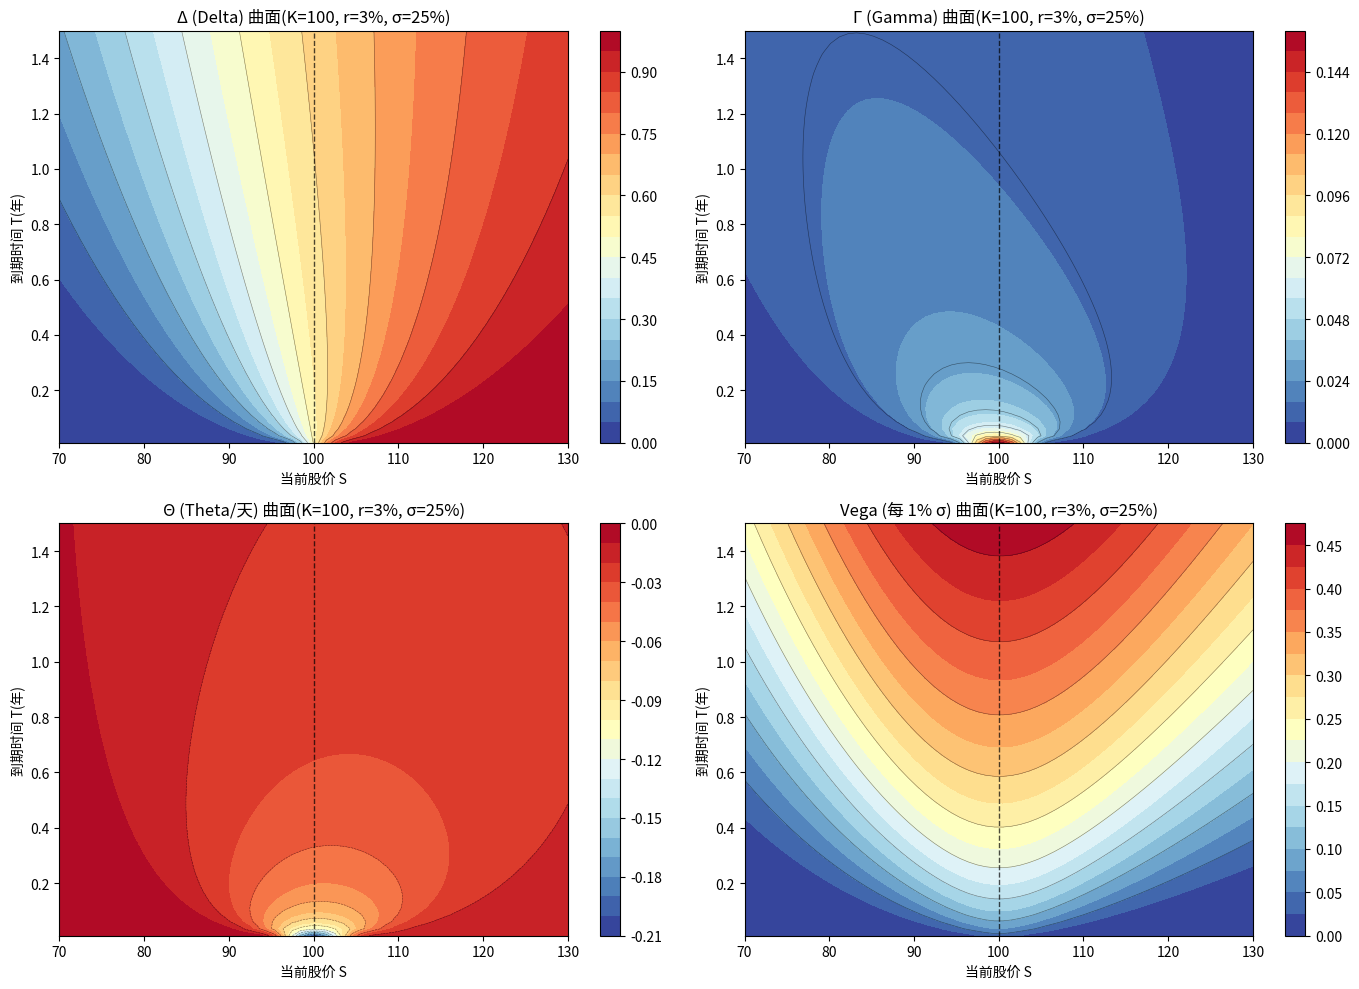

In [3]:
# day_021_greeks.py — 希腊字母 Δ Γ Θ Vega Rho 全解析
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
np.random.seed(42)

# ============ 1. BS 公式与希腊字母全实现 ============
def bs_call(S, K, r, sigma, T):
    if T <= 0: return max(S - K, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

def greeks_call(S, K, r, sigma, T):
    """返回 (Δ, Γ, Θ, Vega, Rho) 五个希腊字母"""
    if T <= 0:
        return (1.0 if S > K else 0.0, 0.0, 0.0, 0.0, 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta_year = (- S * norm.pdf(d1) * sigma / (2*np.sqrt(T))
                  - r * K * np.exp(-r*T) * norm.cdf(d2))
    theta_day = theta_year / 252
    vega = S * norm.pdf(d1) * np.sqrt(T)        # 对 σ 的导数(σ 单位 1.0=100%)
    vega_per_pct = vega / 100                    # σ 变 1%(0.01)时期权价变
    rho = K * T * np.exp(-r*T) * norm.cdf(d2)
    rho_per_pct = rho / 100                      # r 变 1% 时期权价变
    return delta, gamma, theta_day, vega_per_pct, rho_per_pct

# ============ 2. 一份 ATM call 的所有希腊字母值 ============
S, K, r, sigma, T = 100.0, 100.0, 0.03, 0.25, 0.5
price = bs_call(S, K, r, sigma, T)
delta, gamma, theta_day, vega, rho = greeks_call(S, K, r, sigma, T)
print(f'=== ATM call 希腊字母(S={S}, K={K}, r={r:.0%}, σ={sigma:.0%}, T={T}y)===')
print(f'BS 价格 = {price:.4f}')
print(f'Δ (Delta) = {delta:.4f}     标的涨 1 元 → 期权涨 {delta:.4f} 元')
print(f'Γ (Gamma) = {gamma:.4f}     标的涨 1 元 → Δ 涨 {gamma:.4f}')
print(f'Θ (Theta/天) = {theta_day:.4f}  每过一天 → 期权损失 {-theta_day:.4f} 元')
print(f'Vega (每 1% σ) = {vega:.4f}    σ 涨 1% → 期权涨 {vega:.4f} 元')
print(f'Rho  (每 1% r) = {rho:.4f}    r 涨 1% → 期权涨 {rho:.4f} 元')

# ============ 3. Δ 跨 strike(深 OTM 到深 ITM)============
print('\n=== Δ 跨 strike(S=100 / σ=25% / T=0.5y)===')
print(f'{"K":>6s} {"Call 价":>10s} {"Δ":>8s} {"Γ":>10s} {"Vega":>10s}')
for K_ in [70, 80, 90, 95, 100, 105, 110, 120, 130]:
    p = bs_call(S, K_, r, sigma, T)
    d, g, _, v, _ = greeks_call(S, K_, r, sigma, T)
    print(f'{K_:6.0f} {p:10.4f} {d:8.4f} {g:10.4f} {v:10.4f}')

# ============ 4. Θ 时间衰减加速(到期前最后一周 Θ 爆炸)============
print('\n=== ATM call 的时间衰减(T 从 1y 到 1 day)===')
print(f'{"T(年)":>10s} {"BS 价":>10s} {"Θ/天":>10s} {"Γ":>10s}')
for T_ in [1.0, 0.5, 0.25, 0.1, 0.05, 0.02, 0.005, 0.002]:
    p = bs_call(S, K, r, sigma, T_)
    d, g, t_day, _, _ = greeks_call(S, K, r, sigma, T_)
    print(f'{T_:10.4f} {p:10.4f} {t_day:10.4f} {g:10.4f}')

# ============ 5. Δ-Γ 中性组合搭建演示 ============
# 卖 1 份 ATM call,用 OTM call 凑 Γ 中性,然后股票凑 Δ 中性
print('\n=== Δ-Γ 中性组合搭建(σ=25%, T=0.5y)===')
S, r, sigma, T = 100.0, 0.03, 0.25, 0.5
call_atm = bs_call(S, 100, r, sigma, T)
d_atm, g_atm, _, _, _ = greeks_call(S, 100, r, sigma, T)
call_otm = bs_call(S, 110, r, sigma, T)
d_otm, g_otm, _, _, _ = greeks_call(S, 110, r, sigma, T)
print(f'ATM call (K=100): 价 {call_atm:.4f} / Δ {d_atm:.4f} / Γ {g_atm:.4f}')
print(f'OTM call (K=110): 价 {call_otm:.4f} / Δ {d_otm:.4f} / Γ {g_otm:.4f}')
# 卖 1 份 ATM,买 X 份 OTM 让 Γ 净 = 0
X = g_atm / g_otm
net_delta = -d_atm + X * d_otm
stock_to_buy = -net_delta  # 买这么多股让 Δ 净 = 0
print(f'\n方案:卖 1 ATM call + 买 {X:.4f} 份 OTM call + 持 {stock_to_buy:.4f} 股股票')
print(f'净 Γ = -{g_atm:.4f} + {X:.4f} × {g_otm:.4f} = {-g_atm + X*g_otm:.4f} ✓')
print(f'净 Δ = -{d_atm:.4f} + {X:.4f} × {d_otm:.4f} + {stock_to_buy:.4f} = {-d_atm + X*d_otm + stock_to_buy:.4f} ✓')

# ============ 6. 五个希腊字母的二维曲面图 ============
S_grid = np.linspace(70, 130, 60)
T_grid = np.linspace(0.01, 1.5, 60)
S_mesh, T_mesh = np.meshgrid(S_grid, T_grid)
delta_mesh = np.zeros_like(S_mesh)
gamma_mesh = np.zeros_like(S_mesh)
theta_mesh = np.zeros_like(S_mesh)
vega_mesh = np.zeros_like(S_mesh)
for i in range(S_mesh.shape[0]):
    for j in range(S_mesh.shape[1]):
        d, g, t, v, _ = greeks_call(S_mesh[i,j], 100, 0.03, 0.25, T_mesh[i,j])
        delta_mesh[i,j] = d
        gamma_mesh[i,j] = g
        theta_mesh[i,j] = t
        vega_mesh[i,j] = v

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, mesh, title, fmt in [
    (axes[0, 0], delta_mesh, 'Δ (Delta)', '%.2f'),
    (axes[0, 1], gamma_mesh, 'Γ (Gamma)', '%.3f'),
    (axes[1, 0], theta_mesh, 'Θ (Theta/天)', '%.3f'),
    (axes[1, 1], vega_mesh, 'Vega (每 1% σ)', '%.3f'),
]:
    cs = ax.contourf(S_mesh, T_mesh, mesh, levels=20, cmap='RdYlBu_r')
    ax.contour(S_mesh, T_mesh, mesh, levels=10, colors='black', linewidths=0.4, alpha=0.5)
    fig.colorbar(cs, ax=ax)
    ax.axvline(100, color='black', linestyle='--', alpha=0.7, linewidth=1)
    ax.set_title(f'{title} 曲面(K=100, r=3%, σ=25%)')
    ax.set_xlabel('当前股价 S'); ax.set_ylabel('到期时间 T(年)')

plt.tight_layout()
plt.savefig('day021_greeks.png', dpi=150, bbox_inches='tight')
print('\n✓ 图已保存到 day021_greeks.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 1976-1987 组合保险 | Rubinstein-Leland portfolio insurance | Rubinstein 和 Leland 一九七六年提出动态 Δ 对冲来给组合做「保险」,等价于持有一份合成 put。一九八零年代风靡华尔街,资金管理规模数百亿。一九八七年黑色星期一股价跳跌 Δ 调整不及,组合保险全部失灵 → 直接放大了崩盘 → 希腊字母实战意识从此普及。 |
| 1990s 华尔街期权台 | Goldman Sachs / Morgan Stanley | 做市商每天监控数千份期权头寸的 Δ Γ Vega Theta 净值,目标是 |Δ| < 5% / |Γ| < 0.5 / |Vega| < 数千美元 / Theta 正(收时间价值)。希腊字母从 BS 公式变成屏幕上每秒刷新的实时数字 — 这是金融工程从教科书走入交易厅的标志。 |
| 1998 LTCM 倒闭 | 长期资本 | LTCM 用 BS + 希腊字母管头寸,Vega 暴露巨大但被忽视。一九九八年俄罗斯违约 → 全市场 vol 飙升 → LTCM Vega 损失爆炸 → 几个月内 46 亿美元蒸发。这是希腊字母「Vega 不可被忽视」最惨痛的教训。 |
| 2020-03 疫情 | SPX 期权 | 美股一周熔断 4 次,VIX 从 17 飙到 82(+65 vol)。做空 Vega 头寸瞬间巨亏,做多 Vega 头寸暴富。这次事件再次提醒:Vega 是「波动率的波动率」,不可掉以轻心。 |
| 2021-01 GameStop | GME 期权 | 散户聚集 WSB 大量买 OTM call → Γ 飙升 → 做市商被迫买股票对冲 Δ → 股价进一步涨 → 更多 OTM call 进入 ITM → Γ 进一步炸 → 死循环。这是 Γ 暴露在散户手里的极端案例,GME 三天涨 600%。 |


## 常见坑

### ⚠ 01. 只看 Δ 不看 Γ

Δ 中性 ≠ 安全。如果你 Γ 大(比如卖 ATM 短期 call),股价剧烈波动时损失 ≈ 0.5 × Γ × dS²。一九八七组合保险全部死于这一点。**必须同时看 Δ 和 Γ**,做市商屏幕上从来都是两者并列。

### ⚠ 02. Theta 收割没控 Γ 和 Vega

卖期权(short premium)赚 Theta 看起来稳定,但承担 Γ 和 Vega 风险。一旦市场跳跃(财报 / 危机),Γ 损失 + Vega 涨损失会数倍 / 数十倍超过 Theta 收益。**新手最常见死法:连续卖 ATM 周期权,赚 6 个月一笔回吐光**。

### ⚠ 03. 用希腊字母平均覆盖 IV 微笑

希腊字母假设 σ 是单一数值。实战 IV 是行权价 K 的函数(微笑)。**用一个 σ 算所有 K 的希腊字母会系统性偏离市场实际**。专业做法:每份期权用自己 IV 算希腊,组合管理时按 IV surface 加权。

### ⚠ 04. Vega 当 Theta 一样收

做空 Vega 是一个很常见的策略(比如卖 long-term ATM call),但 Vega 风险跟 Theta 不一样 — Theta 是确定的(每天 -X),Vega 是随机的(VIX 涨可瞬间损失数十倍)。**长期 short Vega 仓位必须配 vol 上行保护(比如 buy long-term OTM put)**。

### ⚠ 05. 希腊字母在跳跃市失效

希腊字母都是 BS 模型(GBM 假设)的产物。BS 假设连续路径,跳跃事件下 Δ 来不及调,Γ 损失爆炸,Vega 跳变。**财报前后 / 黑天鹅事件 / 加密剧烈波动时不能依赖希腊字母**,要用 scenario analysis(模拟极端情景)而非希腊敞口。

## 实战 SOP · 希腊字母实战 SOP

1. **Δ 中性是入门 / Δ-Γ 中性是合格 / Δ-Γ-Vega 中性是专业** — 实战至少做到 Δ-Γ 中性
2. 高 Γ 头寸(卖 ATM 短期)要勤调对冲(每日多次),低 Γ 头寸(深 OTM/ITM)可以低频(每日一次)
3. 卖期权(short premium)收 Theta 不要超过组合 Vega 风险的 10 分之 1,否则单事件冲击直接爆仓
4. **临近到期(T < 1 周)避开 ATM 头寸** — Γ Theta 全部爆炸,新手最容易踩坑
5. 希腊字母在「IV 平稳 + 路径连续」假设下精确,实战要用 IV surface + 跳跃概率修正
6. Vega 是「波动率的波动率」 — 长期 short Vega 必须配上行保护,LTCM 教训
7. 看希腊字母数字别孤立看,要对照「我对市场什么观点」 → Δ 反映方向 / Γ 反映波动 / Vega 反映 IV / Theta 反映时间

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 5 个希腊字母 = BS 公式对 5 个变量的导数。Δ 对 S 一阶 / Γ 对 S 二阶 / Θ 对 t / Vega 对 σ / Rho 对 r
3. Δ = N(d₁) 是对冲股数。深 ITM 接近 1 / ATM 约 0.57 / 深 OTM 接近 0
4. Γ 最大不在 spot-ATM(K=S)而在 forward-ATM(K* = S × exp((r+σ²/2)T))— 实测 K=105 Γ=0.0224 比 K=100 略高
5. Θ 临近到期爆炸 — T=5 天 Θ=-0.29 元/天 是 T=1 年 Θ=-0.025 的 11 倍。最后一周 Theta 损失最快
6. Vega 跨 strike 跟 Γ 同形状 — ATM 最大,深 ITM/OTM 都小。卖 ATM = 收最多 vega 风险
7. Δ-Γ 中性组合实测:卖 1 ATM call + 买 1.05 OTM call + 持 0.19 股股票 → 净 Δ=0 + 净 Γ=0。这就是期权交易员日常工作

## 自测题

**Q1.** ATM call 的 Δ 大约是多少?为什么不是恰好 0.5?(提示:d_1 包含 σ 和 r 项)

**Q2.** Γ 在什么条件下最大?为什么期权交易员讨厌做空 ATM 短期期权?

**Q3.** Theta 为什么 ~ 1/√T?这意味着 1 周期 ATM call 的每天 Theta 是 1 月期的几倍?

**Q4.** Vega 在什么条件下最大?为什么财报前后买长期 ATM call 是赌 Vega?

**Q5.** 你卖一份 ATM call(Δ=0.55, Γ=0.04),买 X 份 OTM call(Δ=0.30, Γ=0.025)凑 Γ 中性,X 是多少?然后股票凑 Δ 中性需要多少股?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 022 · 订单簿基础** (Order Book 101)

下一节(D22 订单簿基础)切换到完全不同的话题 — 不再是衍生品定价,而是市场微结构(market microstructure)。我们看交易所每秒处理数千万订单的撮合机制:买卖盘怎么排队、限价单和市价单的区别、深度怎么影响成交滑点、为什么散户用市价单经常吃亏。市场微结构是从「策略想法」走到「实盘成交」的关键一步,所有量化策略最后都要面对一个真实问题:我的策略产生信号,但订单怎么发?成交价多少?这一节给你工具看穿订单簿。

## 推荐阅读

- Hull《Options, Futures, and Other Derivatives》(11 版,十七章)— 希腊字母全公式 + 实战章节,期权教科书
- Taleb《Dynamic Hedging》(一九九七)— 实务派视角看 Γ Theta Vega 在跳跃市的失效,期权交易员必读
- Rubinstein, Leland《Replicating Options with Positions in Stock and Cash》(FAJ 一九八一)— 组合保险论文,希腊字母从教科书到实战的标志
- Black《How We Came Up With The Option Formula》(JPM 一九八九)— Black 自己回忆 BS 推导过程,希腊字母自然涌现
- scipy.stats.norm.cdf + .pdf — Python 算 Δ Γ Theta Vega Rho 的最简工具,本课代码全部基于这两个函数